In [1]:
from pathlib import Path
import re
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_SPLITS = 5

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
DIAG_FIGURES_DIR = FIGURES_DIR / "model_diagnostics"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DIAG_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:80] if text else "unknown"


def find_file(candidate_names, search_dirs):
    for directory in search_dirs:
        for name in candidate_names:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidate_names} in {search_dirs}")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def q2_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    press = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - press / tss)


def make_pls_pipeline(n_components):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components, scale=False, max_iter=200, tol=1e-6)),
    ])


def evaluate_fixed_pls_cv(X_df, y, n_components, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    out_of_fold_pred = np.empty(len(y), dtype=float)
    fold_records = []

    for fold_id, (train_idx, val_idx) in enumerate(cv.split(X_df), start=1):
        model = make_pls_pipeline(n_components)
        model.fit(X_df.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X_df.iloc[val_idx]).ravel()
        out_of_fold_pred[val_idx] = pred

        fold_records.append({
            "fold": fold_id,
            "rmse": rmse(y.iloc[val_idx], pred),
            "mae": float(mean_absolute_error(y.iloc[val_idx], pred)),
            "r2": float(r2_score(y.iloc[val_idx], pred)),
        })

    summary = pd.DataFrame([{
        "n_components": n_components,
        "n_compounds": len(y),
        "rmse_cv_global": rmse(y, out_of_fold_pred),
        "mae_cv_global": float(mean_absolute_error(y, out_of_fold_pred)),
        "q2_cv_global": q2_score(y, out_of_fold_pred),
        "r2_cv_global": float(r2_score(y, out_of_fold_pred)),
        "fold_rmse_mean": float(pd.DataFrame(fold_records)["rmse"].mean()),
        "fold_rmse_sd": float(pd.DataFrame(fold_records)["rmse"].std(ddof=1)),
    }])

    predictions = pd.DataFrame({
        "observed_pIC50": y.values,
        "predicted_pIC50_cv": out_of_fold_pred,
        "residual_cv": y.values - out_of_fold_pred,
    })

    return summary, pd.DataFrame(fold_records), predictions

# 1. Load Raw Data and Previous Outputs

In [2]:
FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx"], [DATA_RAW]),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx"], [DATA_RAW]),
    "admet": find_file(["ADMET.xlsx"], [DATA_RAW]),
}

desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
admet_train = pd.read_excel(FILES["admet"], sheet_name="training")

smiles_col = desc_train.columns[0]
activity_smiles_col = activity_train.columns[0]
admet_smiles_col = admet_train.columns[0]

X_all = desc_train.drop(columns=[smiles_col]).apply(pd.to_numeric, errors="coerce")
y = activity_train["pIC50"].astype(float)

print("Descriptor training shape:", desc_train.shape)
print("Activity training shape:", activity_train.shape)
print("ADMET training shape:", admet_train.shape)
print("X_all shape:", X_all.shape)

Descriptor training shape: (1974, 730)
Activity training shape: (1974, 3)
ADMET training shape: (1974, 6)
X_all shape: (1974, 729)


In [3]:
preprocessing_candidates = pd.read_csv(RESULTS_DIR / "descriptor_preprocessing_candidates.csv")
cv_predictions = pd.read_csv(RESULTS_DIR / "pls_cv_predictions_primary_selected_model.csv")
final_model_summary = pd.read_csv(RESULTS_DIR / "pls_final_model_summary.csv")
pls_scores_saved = pd.read_csv(RESULTS_DIR / "pls_scores_primary_selected_model.csv")
descriptor_importance = pd.read_csv(RESULTS_DIR / "pls_descriptor_importance_primary_selected_model.csv")

pca_outliers = pd.read_csv(RESULTS_DIR / "pca_compound_outlier_summary_empirical.csv")
univar_outliers = pd.read_csv(RESULTS_DIR / "compound_univariate_outlier_summary_modified_z.csv")
activity_outliers = pd.read_csv(RESULTS_DIR / "activity_outlier_summary_iqr.csv")

for col in ["is_constant", "is_near_constant", "is_binary_like", "is_rare_binary_like"]:
    if col in preprocessing_candidates.columns:
        preprocessing_candidates[col] = preprocessing_candidates[col].fillna(False).astype(bool)

preprocessing_candidates["candidate_super_block"] = (
    preprocessing_candidates.get("candidate_super_block", "not_assigned")
    .fillna("not_assigned")
)

display(final_model_summary)
display(cv_predictions.head())

,dataset_name,n_descriptors,selected_n_components,best_rmse_n_components,training_rmse,training_mae,training_r2,cv_rmse_global,cv_mae_global,cv_q2_global
0,primary_remove_constant_only,504,20,43,0.728975,0.560801,0.737444,0.855541,0.641078,0.638359


,SMILES,dataset_name,n_components,y_true,y_pred_cv,residual_cv,pIC50,observed_pIC50,predicted_pIC50_cv,abs_residual_cv
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,primary_remove_constant_only,20,8.602060,8.396612,0.205448,8.602060,8.602060,8.396612,0.205448
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,primary_remove_constant_only,20,8.124939,8.359938,-0.234999,8.124939,8.124939,8.359938,0.234999
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,primary_remove_constant_only,20,8.508638,8.395721,0.112918,8.508638,8.508638,8.395721,0.112918
3,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.408935,8.042350,0.366586,8.408935,8.408935,8.042350,0.366586
4,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.130768,8.219313,-0.088545,8.130768,8.130768,8.219313,0.088545


# 2. Load the Selected Final PLS Model

In [20]:
final_model = joblib.load(MODEL_DIR / "final_pls_model_primary_selected.joblib")

model_metadata = pd.read_csv(MODEL_DIR / "final_pls_model_metadata.csv")

model_descriptors = pd.read_csv(MODEL_DIR / "final_pls_model_descriptors.csv")["descriptor"].tolist()

display(model_metadata.head())
print("Number of model descriptors:", len(model_descriptors))

X_model_df = X_all[model_descriptors].copy()

if X_model_df.isna().sum().sum() > 0:
    X_model_df = X_model_df.fillna(X_model_df.median())

final_scaler = final_model.named_steps["scaler"]
final_pls = final_model.named_steps["pls"]

X_model_scaled = final_scaler.transform(X_model_df)

print("Loaded final model:")
print(final_model)

,selected_dataset_name,selected_n_components,n_descriptors,n_compounds,response
0,primary_remove_constant_only,20,504,1974,pIC50


Number of model descriptors: 504
Loaded final model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('pls',
                 PLSRegression(max_iter=200, n_components=20, scale=False))])


# 3. Mark High-Residual Compounds

In [21]:
error_df = cv_predictions.copy()

error_df["SMILES"] = error_df["SMILES"].astype(str)

residual_sd = error_df["residual_cv"].std(ddof=1)
residual_median = error_df["residual_cv"].median()
residual_mad = (error_df["residual_cv"] - residual_median).abs().median()

error_df["standardised_residual_cv"] = error_df["residual_cv"] / residual_sd

if residual_mad > 0:
    error_df["robust_z_residual_cv"] = 0.6745 * (error_df["residual_cv"] - residual_median) / residual_mad
else:
    error_df["robust_z_residual_cv"] = np.nan

large_residual_cutoff = error_df["abs_residual_cv"].quantile(0.95)

error_df["flag_large_cv_residual_top5pct"] = (
    error_df["abs_residual_cv"] >= large_residual_cutoff
)

error_df["flag_large_cv_residual_z25"] = (
    error_df["standardised_residual_cv"].abs() >= 2.5
)

error_df["flag_large_cv_residual"] = (
    error_df["flag_large_cv_residual_top5pct"]
    | error_df["flag_large_cv_residual_z25"]
)

error_df["prediction_direction"] = np.select(
    [error_df["residual_cv"] > 0, error_df["residual_cv"] < 0],
    ["under_predicted", "over_predicted"],
    default="exact",
)

error_df = error_df.sort_values("abs_residual_cv", ascending=False)

error_df.to_csv(RESULTS_DIR / "pls_high_residual_compounds_primary_selected_model.csv", index=False)

print("Large residual cutoff:", large_residual_cutoff)
print("Number of large-residual compounds:", int(error_df["flag_large_cv_residual"].sum()))
display(error_df.head(30))

Large residual cutoff: 1.6703687765001045
Number of large-residual compounds: 99


,SMILES,dataset_name,n_components,y_true,y_pred_cv,residual_cv,pIC50,observed_pIC50,predicted_pIC50_cv,abs_residual_cv,standardised_residual_cv,robust_z_residual_cv,flag_large_cv_residual_top5pct,flag_large_cv_residual_z25,flag_large_cv_residual,prediction_direction
1110,OCC1=Nc2cc3CCC(N(CC#C)c4ccc(cc4)C(=O)N[C@@H](C...,primary_remove_constant_only,20,9.000000,2.828743,6.171257,9.000000,9.000000,2.828743,6.171257,7.211473,8.503754,True,True,True,under_predicted
1562,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,primary_remove_constant_only,20,6.125518,11.428911,-5.303393,6.125518,6.125518,11.428911,5.303393,-6.197323,-7.364655,True,True,True,over_predicted
1545,CCCCCCCCCCCCCCCCCCNCCOc1ccc(cc1)\C(=C(\CC)/c2c...,primary_remove_constant_only,20,4.000000,8.499150,-4.499150,4.000000,4.000000,8.499150,4.499150,-5.257518,-6.252459,True,True,True,over_predicted
1416,Cn1cc(NC(=O)c2cc(NC(=O)CCS(=O)(=O)C)cn2C)cc1C(...,primary_remove_constant_only,20,8.954677,5.171593,3.783084,8.954677,8.954677,5.171593,3.783084,4.420754,5.201125,True,True,True,under_predicted
1874,CCCCOC(=O)c1cc(I)c(O)c(I)c1,primary_remove_constant_only,20,4.460924,1.289711,3.171213,4.460924,4.460924,1.289711,3.171213,3.705747,4.354963,True,True,True,under_predicted
1415,CC(C)[C@]1(O)CC[C@@]2(C)[C@H](O)CCC(=C)[C@@H]2...,primary_remove_constant_only,20,2.552842,5.631123,-3.078281,2.552842,2.552842,5.631123,3.078281,-3.597150,-4.287525,True,True,True,over_predicted
1412,COc1cc(O)c(\C=C/C(C)(C)O)c2O[C@@H](CC(=O)c12)c...,primary_remove_constant_only,20,2.455932,5.434642,-2.978710,2.455932,2.455932,5.434642,2.978710,-3.480797,-4.149828,True,True,True,over_predicted
1493,COc1ccc(cc1)[C@H]2[C@H](C(O)c3ccc(O)cc3)C(=O)N...,primary_remove_constant_only,20,8.096910,5.223508,2.873402,8.096910,8.096910,5.223508,2.873402,3.357737,3.943116,True,True,True,under_predicted
1103,CC(=CCc1c(O)c(O)cc([C@H]2CCc3ccc(O)cc3O2)c1CC=...,primary_remove_constant_only,20,3.820736,6.630558,-2.809823,3.820736,3.820736,6.630558,2.809823,-3.283441,-3.916272,True,True,True,over_predicted
1525,OC(=O)\C=C\c1ccc(CC2=C(C(=O)Oc3cc(F)ccc23)c4cc...,primary_remove_constant_only,20,5.236572,8.041657,-2.805085,5.236572,5.236572,8.041657,2.805085,-3.277905,-3.909720,True,True,True,over_predicted


# 4. Merge ADMET, PLS Scores, and Existing Outlier Flags

In [22]:
diagnostic_df = error_df.copy()

# ADMET labels
admet_for_merge = admet_train.copy().rename(columns={admet_smiles_col: "SMILES"})
admet_for_merge["SMILES"] = admet_for_merge["SMILES"].astype(str)
diagnostic_df = diagnostic_df.merge(admet_for_merge, on="SMILES", how="left")

# PLS scores saved from 03
pls_scores_for_merge = pls_scores_saved.copy()
pls_scores_for_merge["SMILES"] = pls_scores_for_merge["SMILES"].astype(str)
pls_score_cols = [c for c in pls_scores_for_merge.columns if re.match(r"^T\d+$", str(c))]
diagnostic_df = diagnostic_df.merge(pls_scores_for_merge[["SMILES"] + pls_score_cols], on="SMILES", how="left")

# PCA outlier flags
pca_outliers["SMILES"] = pca_outliers["SMILES"].astype(str)
pca_cols = [c for c in ["SMILES", "flag_pca_outlier_empirical", "flag_reason", "T2_score", "SPE_score"] if c in pca_outliers.columns]
diagnostic_df = diagnostic_df.merge(pca_outliers[pca_cols], on="SMILES", how="left")

diagnostic_df["flag_pca_outlier_empirical"] = diagnostic_df["flag_pca_outlier_empirical"].fillna(False).astype(bool)

# Univariate descriptor outliers
univar_outliers["SMILES"] = univar_outliers["SMILES"].astype(str)
univar_cols = [c for c in ["SMILES", "n_univariate_outlier_descriptors", "prop_univariate_outlier_descriptors"] if c in univar_outliers.columns]
diagnostic_df = diagnostic_df.merge(univar_outliers[univar_cols], on="SMILES", how="left")

# Activity outliers
activity_outliers["SMILES"] = activity_outliers["SMILES"].astype(str)
activity_cols = [c for c in ["SMILES", "flag_pIC50_iqr_outlier", "flag_IC50_nM_iqr_outlier"] if c in activity_outliers.columns]
diagnostic_df = diagnostic_df.merge(activity_outliers[activity_cols], on="SMILES", how="left")

for col in ["flag_pIC50_iqr_outlier", "flag_IC50_nM_iqr_outlier"]:
    if col in diagnostic_df.columns:
        diagnostic_df[col] = diagnostic_df[col].fillna(False).astype(bool)

diagnostic_df.to_csv(RESULTS_DIR / "pls_compound_level_error_diagnostics_initial_merge.csv", index=False)
display(diagnostic_df.head())

,SMILES,dataset_name,n_components,y_true,y_pred_cv,residual_cv,pIC50,observed_pIC50,predicted_pIC50_cv,abs_residual_cv,...,T19,T20,flag_pca_outlier_empirical,flag_reason,T2_score,SPE_score,n_univariate_outlier_descriptors,prop_univariate_outlier_descriptors,flag_pIC50_iqr_outlier,flag_IC50_nM_iqr_outlier
0,OCC1=Nc2cc3CCC(N(CC#C)c4ccc(cc4)C(=O)N[C@@H](C...,primary_remove_constant_only,20,9.000000,2.828743,6.171257,9.000000,9.000000,2.828743,6.171257,...,-4.596183,12.072737,True,T2_only,169.474771,488.437408,36,0.146341,False,False
1,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,primary_remove_constant_only,20,6.125518,11.428911,-5.303393,6.125518,6.125518,11.428911,5.303393,...,-0.488810,-3.657895,True,T2_and_SPE,1394.328481,1453.974704,145,0.589431,False,False
2,CCCCCCCCCCCCCCCCCCNCCOc1ccc(cc1)\C(=C(\CC)/c2c...,primary_remove_constant_only,20,4.000000,8.499150,-4.499150,4.000000,4.000000,8.499150,4.499150,...,-4.468229,-1.859524,False,not_flagged,43.521757,114.956411,18,0.073171,False,True
3,Cn1cc(NC(=O)c2cc(NC(=O)CCS(=O)(=O)C)cn2C)cc1C(...,primary_remove_constant_only,20,8.954677,5.171593,3.783084,8.954677,8.954677,5.171593,3.783084,...,1.981365,6.230928,False,not_flagged,56.452719,405.729275,69,0.280488,False,False
4,CCCCOC(=O)c1cc(I)c(O)c(I)c1,primary_remove_constant_only,20,4.460924,1.289711,3.171213,4.460924,4.460924,1.289711,3.171213,...,6.853334,2.572746,True,T2_only,694.055762,377.786735,8,0.032520,False,True


# 5. PLS Score-Space Leverage and T² Diagnostics

In [23]:
T = final_pls.x_scores_
T_var = T.var(axis=0, ddof=1)
T_var = np.where(T_var <= 1e-12, np.nan, T_var)
pls_t2 = np.nansum((T ** 2) / T_var, axis=1)

# Approximate X residual in the PLS latent space
x_mean = getattr(final_pls, "_x_mean", getattr(final_pls, "x_mean_", None))

if x_mean is not None:
    X_pls_internal = X_model_scaled - np.asarray(x_mean)
else:
    X_pls_internal = X_model_scaled

X_hat_pls = T @ final_pls.x_loadings_.T
pls_x_residual_ss = np.sum((X_pls_internal - X_hat_pls) ** 2, axis=1)

pls_leverage_df = pd.DataFrame({
    "SMILES": desc_train[smiles_col].astype(str).values,
    "PLS_T2_score": pls_t2,
    "PLS_X_residual_ss": pls_x_residual_ss,
})

pls_leverage_df["flag_PLS_T2_ge_99pct"] = pls_leverage_df["PLS_T2_score"] >= pls_leverage_df["PLS_T2_score"].quantile(0.99)
pls_leverage_df["flag_PLS_X_residual_ge_99pct"] = pls_leverage_df["PLS_X_residual_ss"] >= pls_leverage_df["PLS_X_residual_ss"].quantile(0.99)
pls_leverage_df["flag_PLS_score_space_unusual"] = (
    pls_leverage_df["flag_PLS_T2_ge_99pct"]
    | pls_leverage_df["flag_PLS_X_residual_ge_99pct"]
)

pls_leverage_df.to_csv(RESULTS_DIR / "pls_score_space_leverage_diagnostics.csv", index=False)

diagnostic_df = diagnostic_df.merge(pls_leverage_df, on="SMILES", how="left")
diagnostic_df.to_csv(RESULTS_DIR / "pls_compound_level_error_diagnostics.csv", index=False)

display(
    diagnostic_df[[
        "SMILES",
        "observed_pIC50",
        "predicted_pIC50_cv",
        "residual_cv",
        "abs_residual_cv",
        "flag_large_cv_residual",
        "flag_pca_outlier_empirical",
        "flag_reason",
        "flag_PLS_score_space_unusual",
        "PLS_T2_score",
        "PLS_X_residual_ss",
    ]]
    .sort_values("abs_residual_cv", ascending=False)
    .head(30)
)

,SMILES,observed_pIC50,predicted_pIC50_cv,residual_cv,abs_residual_cv,flag_large_cv_residual,flag_pca_outlier_empirical,flag_reason,flag_PLS_score_space_unusual,PLS_T2_score,PLS_X_residual_ss
0,OCC1=Nc2cc3CCC(N(CC#C)c4ccc(cc4)C(=O)N[C@@H](C...,9.000000,2.828743,6.171257,6.171257,True,True,T2_only,True,144.636432,724.383832
1,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,6.125518,11.428911,-5.303393,5.303393,True,True,T2_and_SPE,True,1063.860788,3176.251750
2,CCCCCCCCCCCCCCCCCCNCCOc1ccc(cc1)\C(=C(\CC)/c2c...,4.000000,8.499150,-4.499150,4.499150,True,False,not_flagged,False,34.098709,213.723633
3,Cn1cc(NC(=O)c2cc(NC(=O)CCS(=O)(=O)C)cn2C)cc1C(...,8.954677,5.171593,3.783084,3.783084,True,False,not_flagged,False,68.819540,517.917686
4,CCCCOC(=O)c1cc(I)c(O)c(I)c1,4.460924,1.289711,3.171213,3.171213,True,True,T2_only,True,165.201055,3290.829384
5,CC(C)[C@]1(O)CC[C@@]2(C)[C@H](O)CCC(=C)[C@@H]2...,2.552842,5.631123,-3.078281,3.078281,True,False,not_flagged,False,46.450459,321.149888
6,COc1cc(O)c(\C=C/C(C)(C)O)c2O[C@@H](CC(=O)c12)c...,2.455932,5.434642,-2.978710,2.978710,True,False,not_flagged,False,11.183287,93.370737
7,COc1ccc(cc1)[C@H]2[C@H](C(O)c3ccc(O)cc3)C(=O)N...,8.096910,5.223508,2.873402,2.873402,True,False,not_flagged,False,16.145343,362.551032
8,CC(=CCc1c(O)c(O)cc([C@H]2CCc3ccc(O)cc3O2)c1CC=...,3.820736,6.630558,-2.809823,2.809823,True,False,not_flagged,False,15.930277,136.669472
9,OC(=O)\C=C\c1ccc(CC2=C(C(=O)Oc3cc(F)ccc23)c4cc...,5.236572,8.041657,-2.805085,2.805085,True,False,not_flagged,False,26.661993,131.801504


# 6. Calibration and Residual Pattern Across the Activity Range

In [36]:
diagnostic_df["pIC50_bin"] = pd.qcut(
    diagnostic_df["observed_pIC50"],
    q=5,
    duplicates="drop",
).astype(str)

residual_by_activity_bin = (
    diagnostic_df
    .groupby("pIC50_bin")
    .agg(
        n_compounds=("SMILES", "count"),
        mean_observed_pIC50=("observed_pIC50", "mean"),
        mean_predicted_pIC50=("predicted_pIC50_cv", "mean"),
        mean_residual=("residual_cv", "mean"),
        median_residual=("residual_cv", "median"),
        mean_abs_residual=("abs_residual_cv", "mean"),
        median_abs_residual=("abs_residual_cv", "median"),
        prop_large_residual=("flag_large_cv_residual", "mean"),
    )
    .reset_index()
)
residual_by_activity_bin = residual_by_activity_bin.sort_values("mean_observed_pIC50").reset_index(drop=True)
residual_by_activity_bin.to_csv(RESULTS_DIR / "pls_residual_by_observed_pIC50_bin.csv", index=False)
display(residual_by_activity_bin)

,pIC50_bin,n_compounds,mean_observed_pIC50,mean_predicted_pIC50,mean_residual,median_residual,mean_abs_residual,median_abs_residual,prop_large_residual
0,"(2.455, 5.16]",395,4.675306,5.090216,-0.414910,-0.372098,0.749749,0.562934,0.091139
1,"(5.16, 6.126]",395,5.640437,6.075295,-0.434858,-0.365649,0.643847,0.482863,0.060759
2,"(6.126, 6.963]",396,6.570006,6.672367,-0.102361,-0.017795,0.518792,0.387415,0.017677
3,"(6.963, 7.921]",397,7.382597,7.045278,0.337319,0.314686,0.563752,0.483144,0.017632
4,"(7.921, 10.337]",391,8.679420,8.048976,0.630444,0.531486,0.730861,0.562918,0.063939


In [37]:
diagnostic_df["predicted_pIC50_bin"] = pd.qcut(
    diagnostic_df["predicted_pIC50_cv"],
    q=5,
    duplicates="drop",
).astype(str)

residual_by_predicted_bin = (
    diagnostic_df
    .groupby("predicted_pIC50_bin")
    .agg(
        n_compounds=("SMILES", "count"),
        mean_predicted_pIC50=("predicted_pIC50_cv", "mean"),
        mean_observed_pIC50=("observed_pIC50", "mean"),
        mean_residual=("residual_cv", "mean"),
        median_residual=("residual_cv", "median"),
        mean_abs_residual=("abs_residual_cv", "mean"),
        median_abs_residual=("abs_residual_cv", "median"),
        prop_large_residual=("flag_large_cv_residual", "mean"),
    )
    .reset_index()
)

residual_by_predicted_bin = residual_by_predicted_bin.sort_values("mean_predicted_pIC50").reset_index(drop=True)
residual_by_predicted_bin.to_csv(RESULTS_DIR / "pls_residual_by_predicted_pIC50_bin.csv", index=False)
display(residual_by_predicted_bin)

,predicted_pIC50_bin,n_compounds,mean_predicted_pIC50,mean_observed_pIC50,mean_residual,median_residual,mean_abs_residual,median_abs_residual,prop_large_residual
0,"(1.2890000000000001, 5.543]",395,4.810594,4.977927,0.167333,0.060453,0.588121,0.438692,0.043038
1,"(5.543, 6.299]",395,5.956925,5.859192,-0.097733,-0.132037,0.622545,0.495107,0.030380
2,"(6.299, 6.907]",394,6.583093,6.566396,-0.016697,0.045320,0.676787,0.535018,0.071066
3,"(6.907, 7.639]",395,7.255218,7.285380,0.030162,0.067056,0.679273,0.516129,0.055696
4,"(7.639, 11.429]",395,8.314025,8.241615,-0.072410,0.054510,0.638756,0.479313,0.050633


In [26]:
calibration_coef = np.polyfit(
    diagnostic_df["predicted_pIC50_cv"],
    diagnostic_df["observed_pIC50"],
    deg=1,
)

calibration_slope = calibration_coef[0]
calibration_intercept = calibration_coef[1]

calibration_summary = pd.DataFrame([{
    "calibration_intercept_observed_on_predicted": calibration_intercept,
    "calibration_slope_observed_on_predicted": calibration_slope,
    "mean_residual": diagnostic_df["residual_cv"].mean(),
    "median_residual": diagnostic_df["residual_cv"].median(),
    "rmse_cv": rmse(
        diagnostic_df["observed_pIC50"],
        diagnostic_df["predicted_pIC50_cv"],
    ),
    "mae_cv": mean_absolute_error(
        diagnostic_df["observed_pIC50"],
        diagnostic_df["predicted_pIC50_cv"],
    ),
    "q2_cv": q2_score(
        diagnostic_df["observed_pIC50"],
        diagnostic_df["predicted_pIC50_cv"],
    ),
}])

calibration_summary.to_csv(
    RESULTS_DIR / "pls_cv_calibration_summary.csv",
    index=False,
)

display(calibration_summary)

,calibration_intercept_observed_on_predicted,calibration_slope_observed_on_predicted,mean_residual,median_residual,rmse_cv,mae_cv,q2_cv
0,0.542948,0.91786,0.002141,0.022084,0.855541,0.641078,0.638359


# 7. Residual Pattern Along PLS Latent Score Coordinates

In [27]:
score_trend_records = []
score_bin_records = []

score_cols_to_check = pls_score_cols[:min(len(pls_score_cols), 5)]

for score_col in score_cols_to_check:
    tmp = diagnostic_df[[
        "SMILES",
        score_col,
        "residual_cv",
        "abs_residual_cv",
        "flag_large_cv_residual",
    ]].dropna().copy()

    tmp["score_bin"] = pd.qcut(
        tmp[score_col],
        q=5,
        duplicates="drop",
    ).astype(str)

    score_trend_records.append({
        "score_coordinate": score_col,
        "n_compounds": len(tmp),
        "pearson_corr_score_residual": tmp[score_col].corr(tmp["residual_cv"], method="pearson"),
        "spearman_corr_score_residual": tmp[score_col].corr(tmp["residual_cv"], method="spearman"),
        "pearson_corr_score_abs_residual": tmp[score_col].corr(tmp["abs_residual_cv"], method="pearson"),
        "spearman_corr_score_abs_residual": tmp[score_col].corr(tmp["abs_residual_cv"], method="spearman"),
    })

    bin_summary = (
        tmp
        .groupby("score_bin")
        .agg(
            n_compounds=("SMILES", "count"),
            mean_score=(score_col, "mean"),
            mean_residual=("residual_cv", "mean"),
            median_residual=("residual_cv", "median"),
            mean_abs_residual=("abs_residual_cv", "mean"),
            median_abs_residual=("abs_residual_cv", "median"),
            prop_large_residual=("flag_large_cv_residual", "mean"),
        )
        .reset_index()
        .sort_values("mean_score")
    )

    bin_summary.insert(0, "score_coordinate", score_col)
    score_bin_records.append(bin_summary)

pls_score_residual_trend_summary = pd.DataFrame(score_trend_records)
pls_residual_by_score_bin = pd.concat(score_bin_records, ignore_index=True)

pls_score_residual_trend_summary.to_csv(
    RESULTS_DIR / "pls_score_residual_trend_summary.csv",
    index=False,
)

pls_residual_by_score_bin.to_csv(
    RESULTS_DIR / "pls_residual_by_pls_score_bin.csv",
    index=False,
)

display(pls_score_residual_trend_summary)
display(pls_residual_by_score_bin)

,score_coordinate,n_compounds,pearson_corr_score_residual,spearman_corr_score_residual,pearson_corr_score_abs_residual,spearman_corr_score_abs_residual
0,T1,1974,-0.005770,0.032320,0.073573,0.023826
1,T2,1974,-0.056076,-0.003184,0.155699,0.101464
2,T3,1974,-0.063926,-0.007368,0.061138,-0.025997
3,T4,1974,-0.001425,0.015350,-0.075118,-0.062554
4,T5,1974,-0.012656,-0.016434,0.050614,-0.005693


,score_coordinate,score_bin,n_compounds,mean_score,mean_residual,median_residual,mean_abs_residual,median_abs_residual,prop_large_residual
0,T1,"(-17.762, -7.111]",395,-9.469122,-0.008593,-0.061032,0.562328,0.461328,0.027848
1,T1,"(-7.111, -4.006]",395,-5.762332,0.016664,0.052586,0.589960,0.487804,0.032911
2,T1,"(-4.006, 2.064]",394,-0.898930,-0.000790,0.025701,0.753300,0.587969,0.093909
3,T1,"(2.064, 8.409]",395,5.550345,-0.036062,-0.008197,0.706301,0.529830,0.060759
4,T1,"(8.409, 58.58]",395,10.577763,0.039476,0.074168,0.593786,0.423689,0.035443
5,T2,"(-9.408, -4.265]",395,-5.672989,-0.004054,0.014054,0.536533,0.384862,0.027848
6,T2,"(-4.265, -2.542]",395,-3.454956,-0.035482,0.052586,0.578521,0.461328,0.027848
7,T2,"(-2.542, -0.247]",394,-1.398610,0.049545,0.037382,0.648815,0.504192,0.068528
8,T2,"(-0.247, 3.911]",395,1.686999,0.015622,-0.003715,0.760530,0.619773,0.070886
9,T2,"(3.911, 143.3]",395,8.836015,-0.014807,0.005277,0.681012,0.527411,0.055696


# 8. ADMET Endpoint Distribution Among Large-Residual Compounds

In [28]:
admet_endpoint_cols = [c for c in admet_for_merge.columns if c != "SMILES"]

admet_large_residual_summary = (
    diagnostic_df
    .groupby("flag_large_cv_residual")[admet_endpoint_cols]
    .mean()
    .T
)

admet_large_residual_summary.columns = [
    f"prop_endpoint_1_large_residual_{col}"
    for col in admet_large_residual_summary.columns
]

admet_large_residual_summary = admet_large_residual_summary.reset_index()
admet_large_residual_summary = admet_large_residual_summary.rename(
    columns={"index": "ADMET_endpoint"}
)

false_col = "prop_endpoint_1_large_residual_False"
true_col = "prop_endpoint_1_large_residual_True"

if false_col in admet_large_residual_summary.columns and true_col in admet_large_residual_summary.columns:
    admet_large_residual_summary["difference_large_minus_not_large"] = (
        admet_large_residual_summary[true_col]
        - admet_large_residual_summary[false_col]
    )

admet_large_residual_summary.to_csv(
    RESULTS_DIR / "pls_admet_distribution_by_large_residual_flag.csv",
    index=False,
)

display(admet_large_residual_summary)

,ADMET_endpoint,prop_endpoint_1_large_residual_False,prop_endpoint_1_large_residual_True,difference_large_minus_not_large
0,Caco-2,0.388267,0.313131,-0.075135
1,CYP3A4,0.738667,0.767677,0.029010
2,hERG,0.554667,0.595960,0.041293
3,HOB,0.259200,0.232323,-0.026877
4,MN,0.767467,0.757576,-0.009891


# 9. Overlap Between Large Residuals and Outlier Flags

In [29]:
overlap_records = []

binary_diagnostic_flags = [
    c for c in [
        "flag_pca_outlier_empirical",
        "flag_pIC50_iqr_outlier",
        "flag_IC50_nM_iqr_outlier",
        "flag_PLS_score_space_unusual",
        "flag_PLS_T2_ge_99pct",
        "flag_PLS_X_residual_ge_99pct",
    ]
    if c in diagnostic_df.columns
]

for col in binary_diagnostic_flags:
    tmp = diagnostic_df.copy()
    tmp[col] = tmp[col].fillna(False).astype(bool)
    n_flagged = int(tmp[col].sum())

    overlap_records.append({
        "diagnostic_flag": col,
        "n_flagged_by_diagnostic": n_flagged,
        "n_large_residual_and_flagged": int((tmp["flag_large_cv_residual"] & tmp[col]).sum()),
        "prop_large_residual_among_flagged": float(tmp.loc[tmp[col], "flag_large_cv_residual"].mean()) if n_flagged > 0 else np.nan,
        "prop_diagnostic_flag_among_large_residual": float(tmp.loc[tmp["flag_large_cv_residual"], col].mean()) if tmp["flag_large_cv_residual"].sum() > 0 else np.nan,
    })

# Convert a continuous univariate descriptor-outlier count into an empirical top-1% flag
if "n_univariate_outlier_descriptors" in diagnostic_df.columns:
    tmp = diagnostic_df.copy()
    threshold_many_univar = tmp["n_univariate_outlier_descriptors"].quantile(0.99)
    tmp["flag_many_univariate_descriptor_outliers"] = tmp["n_univariate_outlier_descriptors"] >= threshold_many_univar
    n_flagged = int(tmp["flag_many_univariate_descriptor_outliers"].sum())

    overlap_records.append({
        "diagnostic_flag": "flag_many_univariate_descriptor_outliers",
        "n_flagged_by_diagnostic": n_flagged,
        "n_large_residual_and_flagged": int((tmp["flag_large_cv_residual"] & tmp["flag_many_univariate_descriptor_outliers"]).sum()),
        "prop_large_residual_among_flagged": float(tmp.loc[tmp["flag_many_univariate_descriptor_outliers"], "flag_large_cv_residual"].mean()) if n_flagged > 0 else np.nan,
        "prop_diagnostic_flag_among_large_residual": float(tmp.loc[tmp["flag_large_cv_residual"], "flag_many_univariate_descriptor_outliers"].mean()) if tmp["flag_large_cv_residual"].sum() > 0 else np.nan,
    })

outlier_residual_overlap = pd.DataFrame(overlap_records)
outlier_residual_overlap.to_csv(
    RESULTS_DIR / "pls_large_residual_overlap_with_existing_outlier_flags.csv",
    index=False,
)

display(outlier_residual_overlap)

,diagnostic_flag,n_flagged_by_diagnostic,n_large_residual_and_flagged,prop_large_residual_among_flagged,prop_diagnostic_flag_among_large_residual
0,flag_pca_outlier_empirical,35,5,0.142857,0.050505
1,flag_pIC50_iqr_outlier,0,0,NaN,0.000000
2,flag_IC50_nM_iqr_outlier,309,32,0.103560,0.323232
3,flag_PLS_score_space_unusual,32,5,0.156250,0.050505
4,flag_PLS_T2_ge_99pct,20,5,0.250000,0.050505
5,flag_PLS_X_residual_ge_99pct,20,4,0.200000,0.040404
6,flag_many_univariate_descriptor_outliers,21,4,0.190476,0.040404


# 10. Descriptor Patterns Associated With Large Residuals

In [30]:
# Align diagnostic flags to the descriptor row order
diagnostic_ordered = (
    diagnostic_df
    .set_index("SMILES")
    .loc[desc_train[smiles_col].astype(str).values]
    .reset_index()
)

high_residual_mask = diagnostic_ordered["flag_large_cv_residual"].values.astype(bool)

X_scaled_df = pd.DataFrame(X_model_scaled, columns=model_descriptors)

mean_high_residual = X_scaled_df.loc[high_residual_mask].mean(axis=0)
mean_other = X_scaled_df.loc[~high_residual_mask].mean(axis=0)

descriptor_residual_contrast = pd.DataFrame({
    "descriptor": model_descriptors,
    "mean_standardised_value_high_residual": mean_high_residual.values,
    "mean_standardised_value_other": mean_other.values,
})

descriptor_residual_contrast["mean_difference_high_minus_other"] = (
    descriptor_residual_contrast["mean_standardised_value_high_residual"]
    - descriptor_residual_contrast["mean_standardised_value_other"]
)

descriptor_residual_contrast["abs_mean_difference"] = descriptor_residual_contrast["mean_difference_high_minus_other"].abs()

metadata_cols = [
    "descriptor",
    "descriptor_category",
    "descriptor_numeric_type",
    "candidate_super_block",
    "is_near_constant",
    "is_rare_binary_like",
    "dominant_value_ratio",
]
metadata_cols = [c for c in metadata_cols if c in preprocessing_candidates.columns]

descriptor_residual_contrast = descriptor_residual_contrast.merge(
    preprocessing_candidates[metadata_cols].drop_duplicates("descriptor"),
    on="descriptor",
    how="left",
)

# Merge VIP and coefficient information
vip_cols = [c for c in ["descriptor", "VIP", "VIP_ge_1", "coefficient_standardised_X", "abs_coefficient_standardised_X"] if c in descriptor_importance.columns]
descriptor_residual_contrast = descriptor_residual_contrast.merge(
    descriptor_importance[vip_cols].drop_duplicates("descriptor"),
    on="descriptor",
    how="left",
)

descriptor_residual_contrast = descriptor_residual_contrast.sort_values(
    ["VIP_ge_1", "abs_mean_difference"],
    ascending=[False, False],
)

descriptor_residual_contrast.to_csv(
    RESULTS_DIR / "pls_descriptor_patterns_associated_with_large_residuals.csv",
    index=False,
)

display(descriptor_residual_contrast.head(30))

,descriptor,mean_standardised_value_high_residual,mean_standardised_value_other,mean_difference_high_minus_other,abs_mean_difference,descriptor_category,descriptor_numeric_type,candidate_super_block,is_near_constant,is_rare_binary_like,dominant_value_ratio,VIP,VIP_ge_1,coefficient_standardised_X,abs_coefficient_standardised_X
104,nHBd,0.611050,-0.032263,0.643314,0.643314,Atom type electrotopological state,integer_low_cardinality,block_X_local_electronic_atom_environment,True,False,0.474164,1.021759,True,0.023069,0.023069
423,nHBDon,0.585602,-0.030920,0.616522,0.616522,Hbond donor count,integer_low_cardinality,not_assigned,True,False,0.477204,1.019067,True,0.021047,0.021047
170,SHBd,0.568181,-0.030000,0.598180,0.598180,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.063323,1.122792,True,0.076500,0.076500
116,nHBint10,0.552301,-0.029161,0.581462,0.581462,Atom type electrotopological state,integer_low_cardinality,block_X_local_electronic_atom_environment,True,False,0.501520,1.023305,True,0.063940,0.063940
453,MLFER_A,0.541881,-0.028611,0.570492,0.570492,Molecular linear free energy relation,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.232016,1.765960,True,0.146458,0.146458
362,sumI,0.534617,-0.028228,0.562844,0.562844,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.007092,1.097843,True,0.036678,0.036678
48,nBondsD2,0.519682,-0.027439,0.547121,0.547121,Bond count,integer_low_cardinality,block_Y_topological_connectivity_structure,True,False,0.320162,1.332460,True,0.046001,0.046001
29,ATSm5,0.472879,-0.024968,0.497847,0.497847,Autocorrelation (mass),continuous_float_like,block_Y_topological_connectivity_structure,False,False,0.005572,1.118549,True,0.150822,0.150822
491,TopoPSA,0.452087,-0.023870,0.475957,0.475957,Topological polar surface area,continuous_float_like,not_assigned,False,False,0.053191,1.004016,True,-0.029634,0.029634
155,ndO,0.447230,-0.023614,0.470843,0.470843,Atom type electrotopological state,integer_low_cardinality,block_X_local_electronic_atom_environment,True,False,0.468085,1.435713,True,0.073309,0.073309


# 11. Sensitivity to PCA-Space Outliers

In [31]:
selected_n_components = final_model.named_steps["pls"].n_components
pca_flags = pca_outliers[["SMILES", "flag_pca_outlier_empirical"]].copy()
pca_flags["SMILES"] = pca_flags["SMILES"].astype(str)

row_flags = pd.DataFrame({"SMILES": desc_train[smiles_col].astype(str).values})
row_flags = row_flags.merge(pca_flags, on="SMILES", how="left")
row_flags["flag_pca_outlier_empirical"] = row_flags["flag_pca_outlier_empirical"].fillna(False).astype(bool)

keep_mask = ~row_flags["flag_pca_outlier_empirical"].values

X_without_pca_outliers = X_model_df.loc[keep_mask].reset_index(drop=True)
y_without_pca_outliers = y.loc[keep_mask].reset_index(drop=True)

sensitivity_summary, sensitivity_folds, sensitivity_preds = evaluate_fixed_pls_cv(
    X_without_pca_outliers,
    y_without_pca_outliers,
    n_components=selected_n_components,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

sensitivity_preds.insert(0, "SMILES", desc_train.loc[keep_mask, smiles_col].astype(str).values)
sensitivity_preds["abs_residual_cv"] = sensitivity_preds["residual_cv"].abs()
sensitivity_preds.to_csv(RESULTS_DIR / "pls_sensitivity_to_pca_outlier_removal_predictions.csv", index=False)

sensitivity_summary.insert(0, "analysis", "without_pca_outlier_flagged_compounds")
sensitivity_summary["n_removed_compounds"] = int((~keep_mask).sum())
sensitivity_summary["n_retained_compounds"] = int(keep_mask.sum())

original_summary = pd.DataFrame([{
    "analysis": "main_all_compounds",
    "n_components": selected_n_components,
    "n_compounds": len(y),
    "rmse_cv_global": rmse(error_df["observed_pIC50"], error_df["predicted_pIC50_cv"]),
    "mae_cv_global": float(mean_absolute_error(error_df["observed_pIC50"], error_df["predicted_pIC50_cv"])),
    "q2_cv_global": q2_score(error_df["observed_pIC50"], error_df["predicted_pIC50_cv"]),
    "r2_cv_global": float(r2_score(error_df["observed_pIC50"], error_df["predicted_pIC50_cv"])),
    "n_removed_compounds": 0,
    "n_retained_compounds": len(y),
}])

pca_outlier_sensitivity_summary = pd.concat([original_summary, sensitivity_summary], ignore_index=True)

pca_outlier_sensitivity_summary.to_csv(
    RESULTS_DIR / "pls_sensitivity_to_pca_outlier_removal.csv",
    index=False,
)
sensitivity_folds.to_csv(
    RESULTS_DIR / "pls_sensitivity_to_pca_outlier_removal_fold_metrics.csv",
    index=False,
)

display(pca_outlier_sensitivity_summary)

,analysis,n_components,n_compounds,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,n_removed_compounds,n_retained_compounds,fold_rmse_mean,fold_rmse_sd
0,main_all_compounds,20,1974,0.855541,0.641078,0.638359,0.638359,0,1974,NaN,NaN
1,without_pca_outlier_flagged_compounds,20,1939,0.832313,0.635097,0.655393,0.655393,35,1939,0.831736,0.034714


# 12. Diagnostic Plots

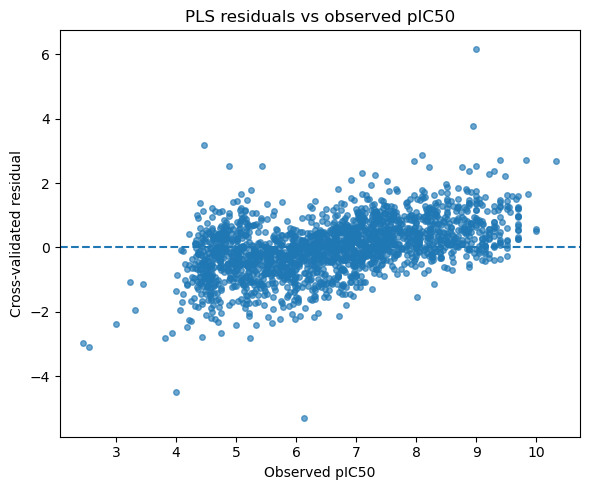

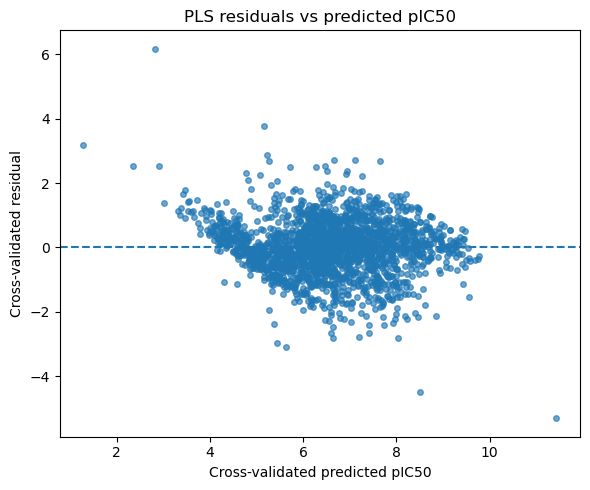

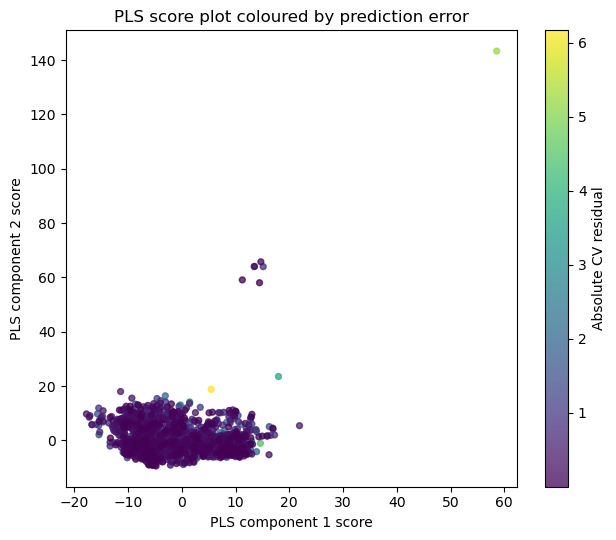

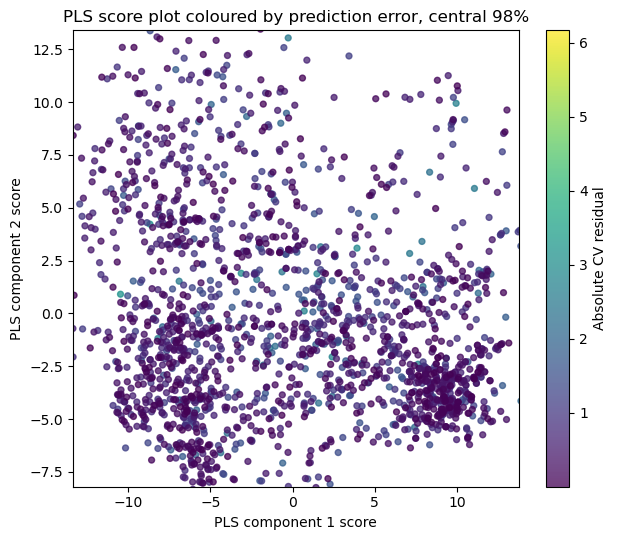

In [32]:
# Residuals vs observed pIC50
plt.figure(figsize=(6, 5))
plt.scatter(
    diagnostic_df["observed_pIC50"],
    diagnostic_df["residual_cv"],
    s=16,
    alpha=0.65,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Observed pIC50")
plt.ylabel("Cross-validated residual")
plt.title("PLS residuals vs observed pIC50")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_residuals_vs_observed_pIC50.png", dpi=200)
plt.show()

# Residuals vs predicted pIC50
plt.figure(figsize=(6, 5))
plt.scatter(
    diagnostic_df["predicted_pIC50_cv"],
    diagnostic_df["residual_cv"],
    s=16,
    alpha=0.65,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Cross-validated predicted pIC50")
plt.ylabel("Cross-validated residual")
plt.title("PLS residuals vs predicted pIC50")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_residuals_vs_predicted_pIC50.png", dpi=200)
plt.show()

# PLS score plot coloured by absolute prediction error
plt.figure(figsize=(6.5, 5.5))
scatter = plt.scatter(
    diagnostic_df["T1"],
    diagnostic_df["T2"],
    c=diagnostic_df["abs_residual_cv"],
    s=18,
    alpha=0.75,
)
plt.colorbar(scatter, label="Absolute CV residual")
plt.xlabel("PLS component 1 score")
plt.ylabel("PLS component 2 score")
plt.title("PLS score plot coloured by prediction error")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_score_plot_coloured_by_abs_residual.png", dpi=200)
plt.show()

# Zoomed PLS score plot to avoid extreme points compressing the main cloud
x_low, x_high = diagnostic_df["T1"].quantile([0.01, 0.99])
y_low, y_high = diagnostic_df["T2"].quantile([0.01, 0.99])

plt.figure(figsize=(6.5, 5.5))
scatter = plt.scatter(
    diagnostic_df["T1"],
    diagnostic_df["T2"],
    c=diagnostic_df["abs_residual_cv"],
    s=18,
    alpha=0.75,
)
plt.colorbar(scatter, label="Absolute CV residual")
plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)
plt.xlabel("PLS component 1 score")
plt.ylabel("PLS component 2 score")
plt.title("PLS score plot coloured by prediction error, central 98%")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_score_plot_coloured_by_abs_residual_zoomed.png", dpi=200)
plt.show()

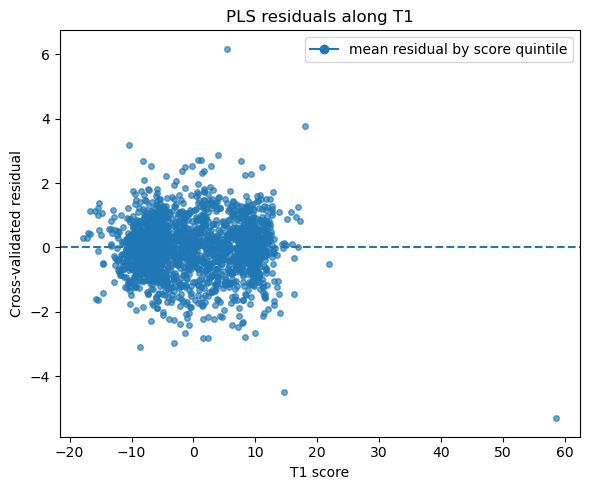

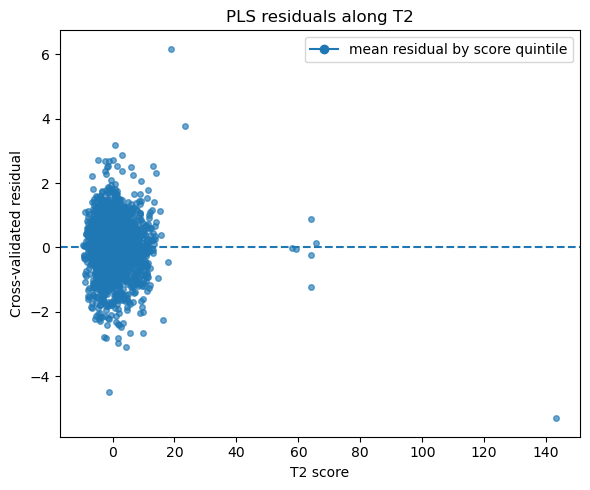

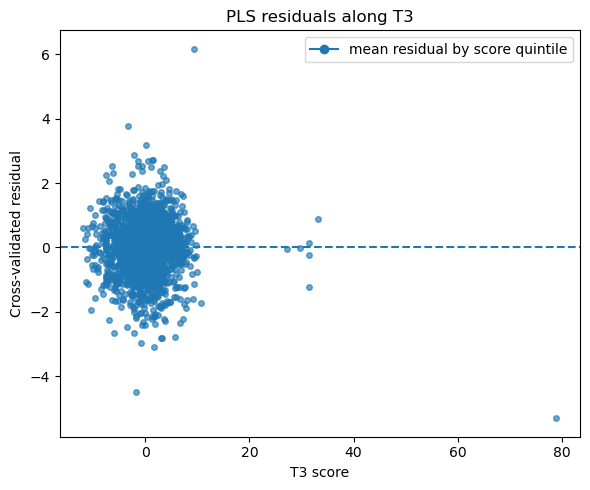

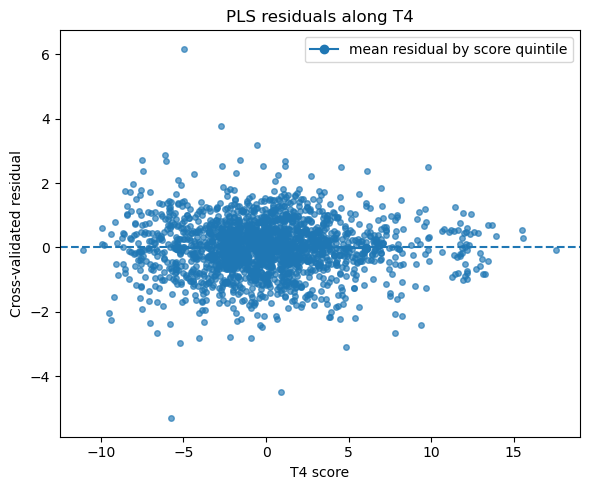

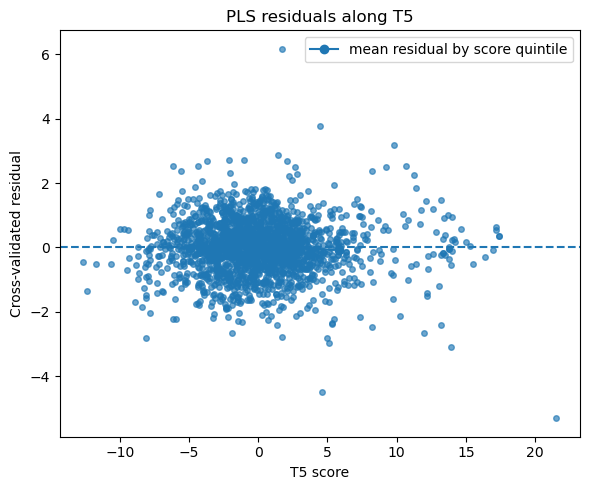

In [33]:
for score_col in score_cols_to_check:
    plt.figure(figsize=(6, 5))
    plt.scatter(
        diagnostic_df[score_col],
        diagnostic_df["residual_cv"],
        s=16,
        alpha=0.65,
    )
    plt.axhline(0, linestyle="--")

    tmp_bin = pls_residual_by_score_bin[
        pls_residual_by_score_bin["score_coordinate"] == score_col
    ].sort_values("mean_score")

    plt.plot(
        tmp_bin["mean_score"],
        tmp_bin["mean_residual"],
        marker="o",
        label="mean residual by score quintile",
    )

    plt.xlabel(f"{score_col} score")
    plt.ylabel("Cross-validated residual")
    plt.title(f"PLS residuals along {score_col}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIAG_FIGURES_DIR / f"pls_residuals_vs_{score_col}.png", dpi=200)
    plt.show()

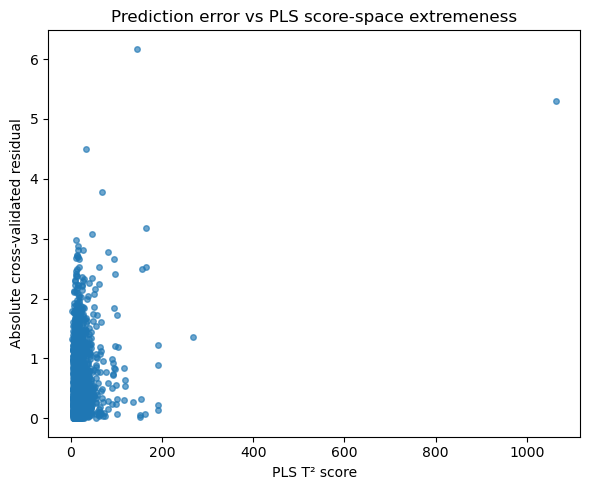

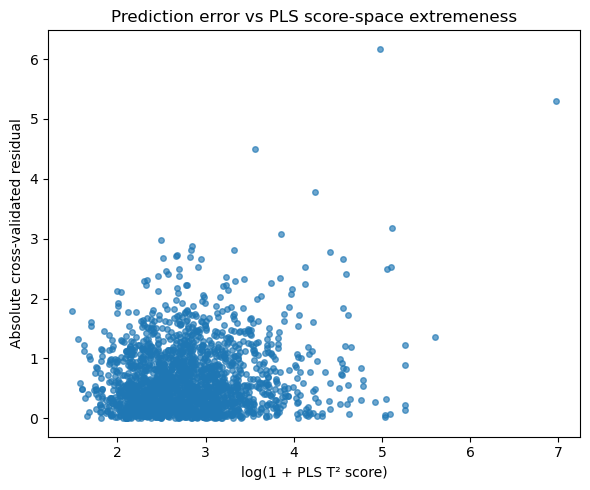

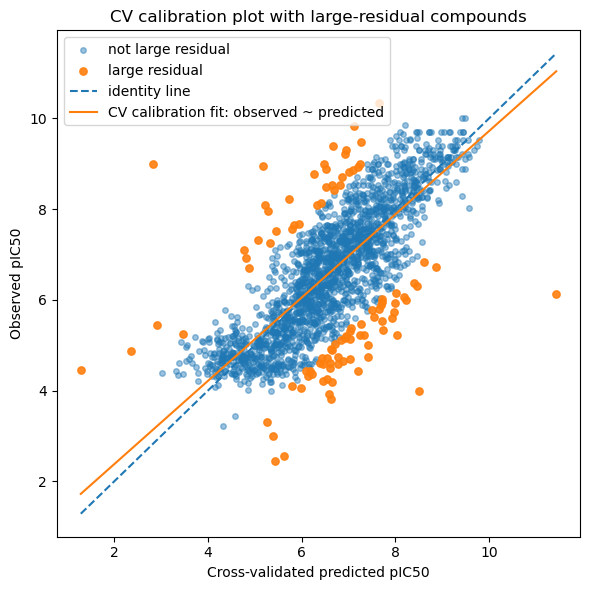

In [34]:
# Prediction error vs PLS score-space extremeness
plt.figure(figsize=(6, 5))
plt.scatter(
    diagnostic_df["PLS_T2_score"],
    diagnostic_df["abs_residual_cv"],
    s=16,
    alpha=0.65,
)
plt.xlabel("PLS T² score")
plt.ylabel("Absolute cross-validated residual")
plt.title("Prediction error vs PLS score-space extremeness")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_abs_residual_vs_pls_t2.png", dpi=200)
plt.show()

# Log-scale version for readability when a few points have very large T²
plt.figure(figsize=(6, 5))
plt.scatter(
    np.log1p(diagnostic_df["PLS_T2_score"]),
    diagnostic_df["abs_residual_cv"],
    s=16,
    alpha=0.65,
)
plt.xlabel("log(1 + PLS T² score)")
plt.ylabel("Absolute cross-validated residual")
plt.title("Prediction error vs PLS score-space extremeness")
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_abs_residual_vs_log1p_pls_t2.png", dpi=200)
plt.show()

# Observed vs predicted with high-residual compounds highlighted
plt.figure(figsize=(6, 6))

not_large = ~diagnostic_df["flag_large_cv_residual"]

plt.scatter(
    diagnostic_df.loc[not_large, "predicted_pIC50_cv"],
    diagnostic_df.loc[not_large, "observed_pIC50"],
    s=16,
    alpha=0.45,
    label="not large residual",
)

plt.scatter(
    diagnostic_df.loc[~not_large, "predicted_pIC50_cv"],
    diagnostic_df.loc[~not_large, "observed_pIC50"],
    s=28,
    alpha=0.9,
    label="large residual",
)

min_val = min(
    diagnostic_df["observed_pIC50"].min(),
    diagnostic_df["predicted_pIC50_cv"].min(),
)
max_val = max(
    diagnostic_df["observed_pIC50"].max(),
    diagnostic_df["predicted_pIC50_cv"].max(),
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="identity line",
)

x_line = np.linspace(min_val, max_val, 100)
y_cal = calibration_intercept + calibration_slope * x_line

plt.plot(
    x_line,
    y_cal,
    linestyle="-",
    label="CV calibration fit: observed ~ predicted",
)

plt.xlabel("Cross-validated predicted pIC50")
plt.ylabel("Observed pIC50")
plt.title("CV calibration plot with large-residual compounds")
plt.legend()
plt.tight_layout()
plt.savefig(DIAG_FIGURES_DIR / "pls_cv_calibration_plot_high_residual_highlighted.png", dpi=200)
plt.show()

# 13. Diagnostic Summary

In [35]:
diagnostic_summary = pd.DataFrame([{
    "selected_dataset_name": model_metadata["selected_dataset_name"].iloc[0],
    "selected_n_components": selected_n_components,
    "n_compounds": len(diagnostic_df),
    "n_large_cv_residual": int(diagnostic_df["flag_large_cv_residual"].sum()),
    "prop_large_cv_residual": float(diagnostic_df["flag_large_cv_residual"].mean()),
    "n_pca_outlier_flagged": int(diagnostic_df["flag_pca_outlier_empirical"].sum()) if "flag_pca_outlier_empirical" in diagnostic_df.columns else np.nan,
    "n_large_residual_and_pca_outlier": int((diagnostic_df["flag_large_cv_residual"] & diagnostic_df["flag_pca_outlier_empirical"]).sum()) if "flag_pca_outlier_empirical" in diagnostic_df.columns else np.nan,
    "n_pls_score_space_unusual": int(diagnostic_df["flag_PLS_score_space_unusual"].sum()),
    "n_large_residual_and_pls_score_space_unusual": int((diagnostic_df["flag_large_cv_residual"] & diagnostic_df["flag_PLS_score_space_unusual"]).sum()),
    "calibration_intercept_observed_on_predicted": float(calibration_intercept),
    "calibration_slope_observed_on_predicted": float(calibration_slope),
    "residual_mean": float(diagnostic_df["residual_cv"].mean()),
    "residual_sd": float(diagnostic_df["residual_cv"].std(ddof=1)),
    "abs_residual_median": float(diagnostic_df["abs_residual_cv"].median()),
    "abs_residual_95pct": float(diagnostic_df["abs_residual_cv"].quantile(0.95)),
}])

diagnostic_summary.to_csv(RESULTS_DIR / "pls_model_diagnostics_summary.csv", index=False)
display(diagnostic_summary)

,selected_dataset_name,selected_n_components,n_compounds,n_large_cv_residual,prop_large_cv_residual,n_pca_outlier_flagged,n_large_residual_and_pca_outlier,n_pls_score_space_unusual,n_large_residual_and_pls_score_space_unusual,calibration_intercept_observed_on_predicted,calibration_slope_observed_on_predicted,residual_mean,residual_sd,abs_residual_median,abs_residual_95pct
0,primary_remove_constant_only,20,1974,99,0.050152,35,5,32,5,0.542948,0.91786,0.002141,0.855755,0.488991,1.670369


# 14. Interpretation Notes

The diagnostics in this notebook are descriptive and are not used to remove compounds automatically. They assess where the selected linear PLS model is less adequate.

The global calibration slope is close to one, suggesting that the cross-validated predictions are not severely miscalibrated overall. However, residuals stratified by observed pIC50 reveal activity-range-dependent compression: low-activity compounds tend to be overpredicted, while high-activity compounds tend to be underpredicted.

Residual patterns along PLS score coordinates are interpreted as possible evidence of linear lack-of-fit in the latent descriptor space, not as proof of a specific nonlinear mechanism. These findings motivate building constrained nonlinear calibration models which are fitted in the low-dimensional PLS score space.